# Week 3: Feature Engineering
Tasks:
Compute technical indicators:


Moving Averages (SMA/EMA) 


RSI (Relative Strength Index)
https://www.investopedia.com/terms/r/rsi.asp
Bollinger Bands, MACD
https://www.investopedia.com/terms/b/bollingerbands.asp
https://www.investopedia.com/terms/m/macd.asp


Volatility measures (rolling std)


Derive lag features and rolling stats.


Feature importance correlation matrix.


Milestones:
Enriched feature dataset with at least 8 engineered features.


Visualizations comparing indicators with stock trends.


# load AAPL price data and set Date as index

In [1]:
import pandas as pd

df = pd.read_csv("data/raw/AAPL_price.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)
print(df.head())

                 Open       High        Low      Close     Volume
Date                                                             
2019-01-02  36.896077  37.839383  36.738858  37.617847  148158800
2019-01-03  34.297233  34.711717  33.825582  33.870842  365248800
2019-01-04  34.428245  35.385843  34.254354  35.316761  234428400
2019-01-07  35.421569  35.452537  34.754585  35.238148  219111200
2019-01-08  35.626417  36.164770  35.378682  35.909885  164101200


# Compute Simple & Exponential Moving Averages on loaded df

In [2]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

print(df[['Close','SMA_20','SMA_50','EMA_20','EMA_50']].dropna().head())

                Close     SMA_20     SMA_50     EMA_20     EMA_50
Date                                                             
2019-03-14  43.953705  41.821217  39.493815  41.865322  40.338027
2019-03-15  44.525471  42.004467  39.631968  42.118670  40.502240
2019-03-18  44.980007  42.214989  39.854151  42.391178  40.677839
2019-03-19  44.623547  42.401588  40.040287  42.603785  40.832573
2019-03-20  45.013508  42.594528  40.235794  42.833282  40.996531


# Compute 14-period RSI

In [3]:
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
roll_up   = gain.rolling(window=14).mean()
roll_down = loss.rolling(window=14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

print(df[['Close','RSI_14']].dropna().head())

                Close     RSI_14
Date                            
2019-01-23  36.665020  45.322744
2019-01-24  36.374409  68.601823
2019-01-25  37.579739  67.437648
2019-01-28  37.231945  64.751495
2019-01-29  36.846050  57.232304


# Compute Bollinger Bands + MACD

In [4]:
rolling_mean = df['Close'].rolling(window=20).mean()
rolling_std  = df['Close'].rolling(window=20).std()
df['BB_upper'] = rolling_mean + 2 * rolling_std
df['BB_lower'] = rolling_mean - 2 * rolling_std
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']     = ema12 - ema26
df['MACD_sig'] = df['MACD'].ewm(span=9, adjust=False).mean()

print(df[['Close','BB_upper','BB_lower','MACD','MACD_sig']].dropna().head())

                Close   BB_upper   BB_lower      MACD  MACD_sig
Date                                                           
2019-01-30  39.363922  38.797135  34.357817  0.179842 -0.073108
2019-01-31  39.647385  39.255720  34.102186  0.359946  0.013503
2019-02-01  39.666451  39.519231  34.418236  0.498472  0.110497
2019-02-04  40.793167  40.191118  34.293989  0.691203  0.226638
2019-02-05  41.491112  40.907319  34.203085  0.890004  0.359311


# Compute Rolling Window Volatility Measure

In [5]:
df['Vol_20'] = df['Close'].rolling(window=20).std() # 20 day rolling std of close
df['Vol_50'] = df['Close'].rolling(window=50).std() # 50 day

print(df[['Close','Vol_20','Vol_50']].dropna().head())

                Close    Vol_20    Vol_50
Date                                     
2019-03-14  43.953705  0.902954  2.613630
2019-03-15  44.525471  1.056547  2.693780
2019-03-18  44.980007  1.206387  2.666913
2019-03-19  44.623547  1.277442  2.668545
2019-03-20  45.013508  1.367446  2.667632


# Create Lag Features + Rolling Statistics

In [6]:
for lag in [1, 2, 3, 5, 10]:
    df[f'lag_{lag}'] = df['Close'].shift(lag)

df['roll_min_20']  = df['Close'].rolling(window=20).min()
df['roll_max_20']  = df['Close'].rolling(window=20).max()
df['roll_mean_20'] = df['Close'].rolling(window=20).mean()
df['roll_std_20']  = df['Close'].rolling(window=20).std()

print(df[['Close'] + [f'lag_{l}' for l in [1,2,3,5,10]] +
         ['roll_min_20','roll_max_20','roll_mean_20','roll_std_20']]
      .dropna()
      .head())

                Close      lag_1      lag_2      lag_3      lag_5     lag_10  \
Date                                                                           
2019-01-30  39.363922  36.846050  37.231945  37.579739  36.665020  36.462543   
2019-01-31  39.647385  39.363922  36.846050  37.231945  36.374409  36.907997   
2019-02-01  39.666451  39.647385  39.363922  36.846050  37.579739  37.127148   
2019-02-04  40.793167  39.666451  39.647385  39.363922  37.231945  37.355824   
2019-02-05  41.491112  40.793167  39.666451  39.647385  36.846050  36.517338   

            roll_min_20  roll_max_20  roll_mean_20  roll_std_20  
Date                                                             
2019-01-30    33.870842    39.363922     36.577476     1.109829  
2019-01-31    33.870842    39.647385     36.678953     1.288384  
2019-02-01    35.238148    39.666451     36.968733     1.275249  
2019-02-04    35.238148    40.793167     37.242554     1.474282  
2019-02-05    35.731239    41.491112     37

# Correlation Matrix + Feature Importances

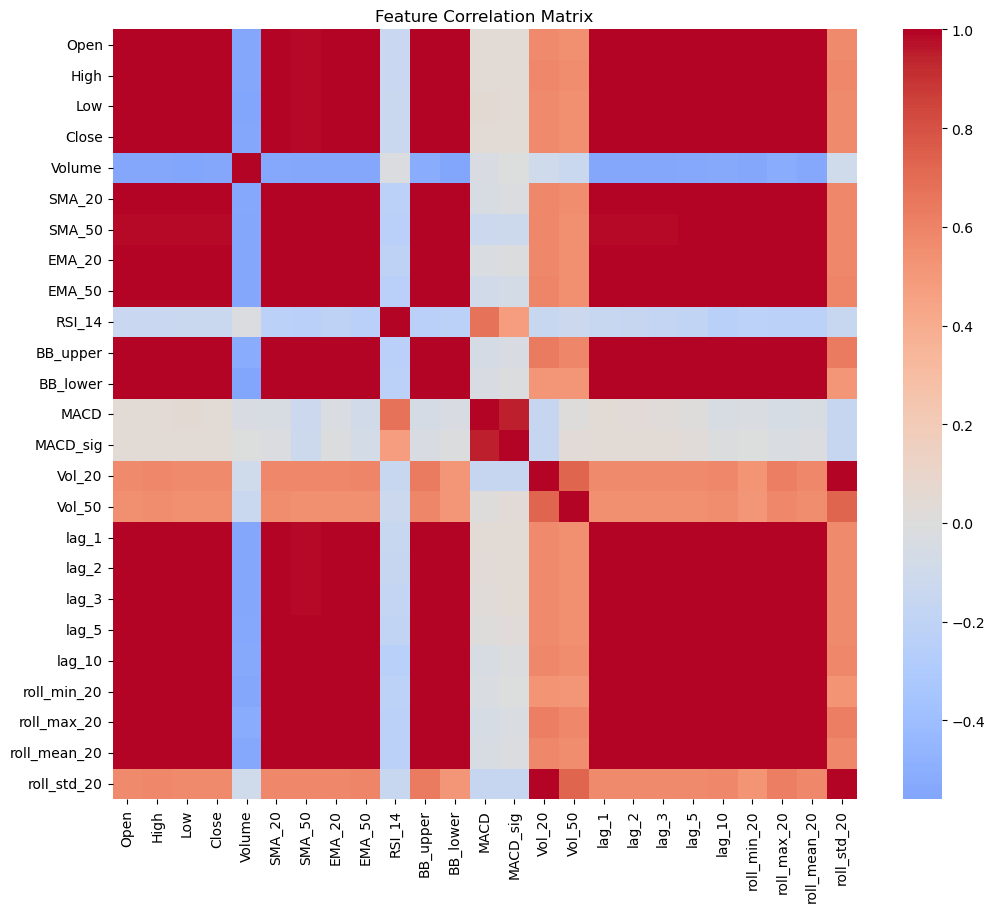

Feature Importances:
High            0.539788
Low             0.402960
Open            0.010966
roll_min_20     0.007322
roll_mean_20    0.005251
SMA_50          0.005194
lag_5           0.004757
lag_1           0.004538
EMA_20          0.004126
BB_lower        0.003207
EMA_50          0.003189
lag_10          0.002954
SMA_20          0.002353
BB_upper        0.002018
lag_3           0.000969
lag_2           0.000110
roll_max_20     0.000105
MACD            0.000078
Volume          0.000024
RSI_14          0.000023
MACD_sig        0.000022
Vol_50          0.000019
Vol_20          0.000016
roll_std_20     0.000013
dtype: float64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

corr = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

features = [c for c in df.columns if c != 'Close']
df_fi = df.dropna(subset=features + ['Close'])
X = df_fi[features]
y = df_fi['Close']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importances:")
print(importances)


# Final Visualizations

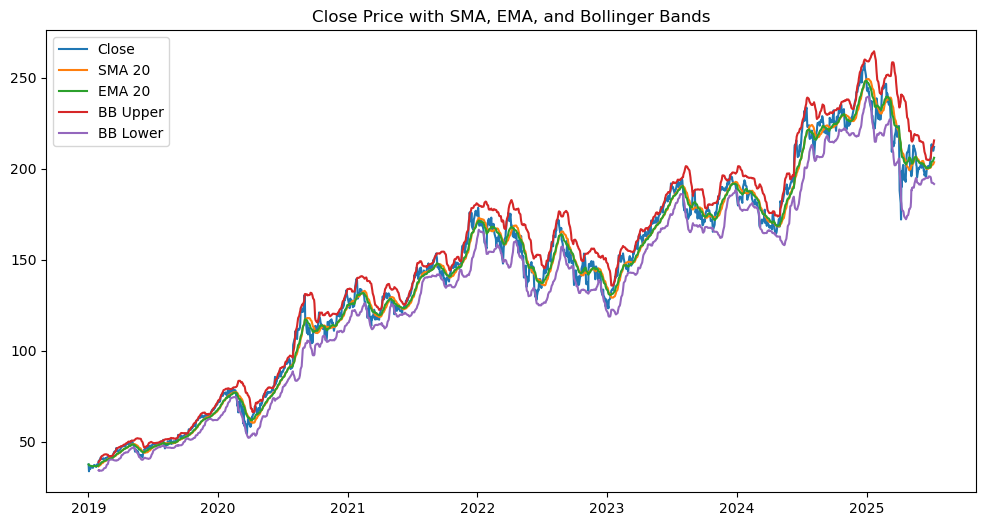

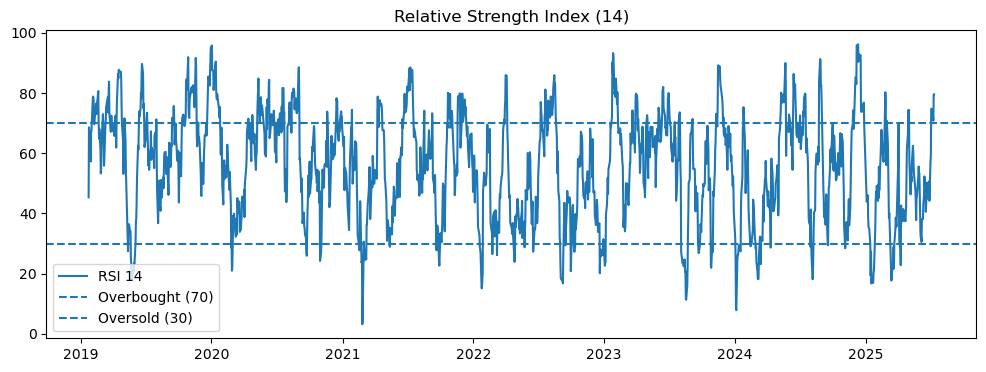

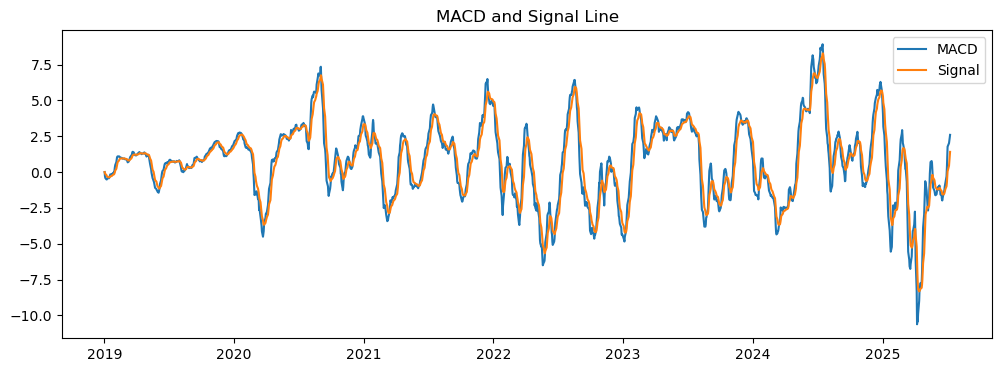

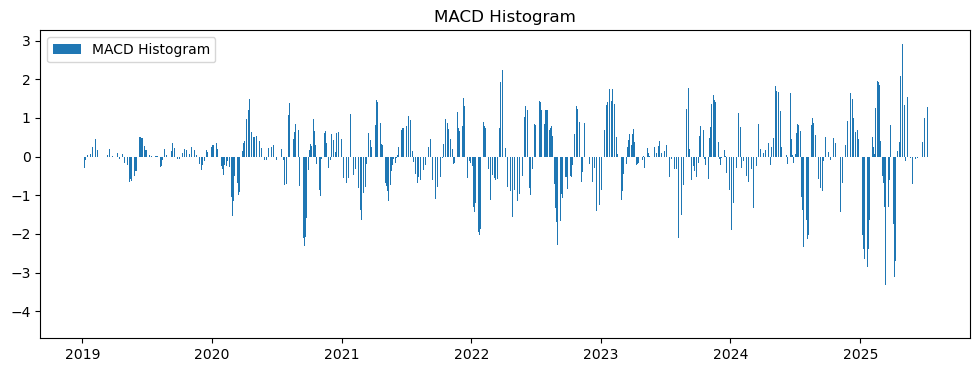

In [8]:
import matplotlib.pyplot as plt

# Price with SMA/EMA + Bollinger Bands
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['Close'],      label='Close')
ax.plot(df.index, df['SMA_20'],      label='SMA 20')
ax.plot(df.index, df['EMA_20'],      label='EMA 20')
ax.plot(df.index, df['BB_upper'],    label='BB Upper')
ax.plot(df.index, df['BB_lower'],    label='BB Lower')
ax.set_title('Close Price with SMA, EMA, and Bollinger Bands')
ax.legend()
plt.show()

# RSI
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['RSI_14'], label='RSI 14')
ax.axhline(70, linestyle='--', label='Overbought (70)')
ax.axhline(30, linestyle='--', label='Oversold (30)')
ax.set_title('Relative Strength Index (14)')
ax.legend()
plt.show()

# MACD & Signal Line
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['MACD'],     label='MACD')
ax.plot(df.index, df['MACD_sig'], label='Signal')
ax.set_title('MACD and Signal Line')
ax.legend()
plt.show()

# MACD Histogram
hist = df['MACD'] - df['MACD_sig']
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df.index, hist, label='MACD Histogram')
ax.set_title('MACD Histogram')
ax.legend()
plt.show()